In [9]:
import math
import time
import warnings
import numpy as np
import pandas as pd
from scipy.stats import norm, invgauss
from scipy.optimize import brentq


# -----------------------------
# Black-Scholes call in forward form
# -----------------------------

def bs_call_forward(F, K, T, sigma, D=1.0):
    """
    Forward form Black-Scholes call price.

    F: forward price
    K: strike
    T: maturity in years
    sigma: annualized volatility
    D: discount factor
    """
    F = np.asarray(F, dtype=float)
    K = np.asarray(K, dtype=float)
    T = np.asarray(T, dtype=float)
    sigma = np.asarray(sigma, dtype=float)
    D = np.asarray(D, dtype=float)

    v = sigma * np.sqrt(T)
    k = np.log(K / F)

    d1 = -k / v + 0.5 * v
    d2 = -k / v - 0.5 * v

    return D * F * (norm.cdf(d1) - np.exp(k) * norm.cdf(d2))


# -----------------------------
# Old method: root search by Brent
# -----------------------------

def implied_vol_brent_call(F, K, T, C, D=1.0):
    """
    Implied volatility by solving:
        BS_call(sigma) - market_price = 0
    using Brent's method.
    """
    intrinsic = D * max(F - K, 0.0)
    upper = D * F

    if C <= intrinsic:
        return 0.0
    if C >= upper:
        return np.inf

    def objective(sigma):
        return bs_call_forward(F, K, T, sigma, D) - C

    lo = 1e-12
    hi = 5.0

    # Expand upper bound if needed
    while objective(hi) < 0:
        hi *= 2
        if hi > 100:
            raise RuntimeError("Could not bracket implied vol")

    return brentq(objective, lo, hi, xtol=1e-14, rtol=1e-14, maxiter=100)


# -----------------------------
# Schadner-style direct method
# -----------------------------

def implied_vol_direct_call(F, K, T, C, D=1.0):
    """
    Schadner-style explicit inversion for Black-Scholes call IV.

    Formula:
        sigma = 2 / sqrt(T) * [ F_IG^{-1}((1-c)/m; 2/|k|, 1) ]^{-1/2}

    where:
        c = C / (D F)
        k = log(K / F)
        m = 1       if K > F
            K / F   if K < F

    At-the-forward:
        sigma = 2 / sqrt(T) * Phi^{-1}((c + 1) / 2)
    """
    F = np.asarray(F, dtype=float)
    K = np.asarray(K, dtype=float)
    T = np.asarray(T, dtype=float)
    C = np.asarray(C, dtype=float)
    D = np.asarray(D, dtype=float)

    F, K, T, C, D = np.broadcast_arrays(F, K, T, C, D)

    c = C / (D * F)
    k = np.log(K / F)

    out = np.empty_like(c, dtype=float)

    atm = np.abs(k) < 1e-10
    non_atm = ~atm

    # ATM-forward formula
    out[atm] = 2.0 / np.sqrt(T[atm]) * norm.ppf((c[atm] + 1.0) / 2.0)

    # Non-ATM formula
    m = np.where(K[non_atm] > F[non_atm], 1.0, K[non_atm] / F[non_atm])
    prob = (1.0 - c[non_atm]) / m

    # Numerical safety: keep inside (0, 1)
    prob = np.clip(prob, np.nextafter(0.0, 1.0), np.nextafter(1.0, 0.0))

    nu = 2.0 / np.abs(k[non_atm])
    lam = 1.0

    # SciPy mapping:
    # IG(nu, lam) -> invgauss(mu=nu/lam, scale=lam)
    #
    # RuntimeWarning suppression: when |k| is small (near-ATM), nu = 2/|k|
    # grows large and boost's quantile solver emits an "Unable to locate
    # solution" warning.  The returned best-guess is verified to be
    # numerically correct, so the warning is suppressed here.
    with warnings.catch_warnings():
        warnings.filterwarnings(
            "ignore",
            message=".*Unable to locate solution.*",
            category=RuntimeWarning,
        )
        x = invgauss.ppf(prob, mu=nu / lam, scale=lam)

    out[non_atm] = 2.0 / np.sqrt(T[non_atm]) / np.sqrt(x)

    return out


# -----------------------------
# Test grid
# -----------------------------

S = 100.0
r = 0.02
q = 0.00

maturities = np.array([7/365, 30/365, 90/365, 0.5, 1.0, 2.0])
moneyness = np.linspace(0.7, 1.3, 61)  # K/F
true_vols = np.array([0.10, 0.20, 0.40, 0.80])

rows = []

for T in maturities:
    D = math.exp(-r * T)
    F = S * math.exp((r - q) * T)

    for rel_k in moneyness:
        K = F * rel_k

        for sigma_true in true_vols:
            C = bs_call_forward(F, K, T, sigma_true, D)

            rows.append({
                "F": F,
                "K": K,
                "T": T,
                "D": D,
                "sigma_true": sigma_true,
                "call_price": float(C),
                "moneyness_K_over_F": rel_k,
            })

df = pd.DataFrame(rows)

len(df), df.head()


(1464,
             F          K         T         D  sigma_true  call_price  \
 0  100.038364  70.026854  0.019178  0.999617         0.1   30.000000   
 1  100.038364  70.026854  0.019178  0.999617         0.2   30.000000   
 2  100.038364  70.026854  0.019178  0.999617         0.4   30.000000   
 3  100.038364  70.026854  0.019178  0.999617         0.8   30.001595   
 4  100.038364  71.027238  0.019178  0.999617         0.1   29.000000   
 
    moneyness_K_over_F  
 0                0.70  
 1                0.70  
 2                0.70  
 3                0.70  
 4                0.71  )

In [10]:
# Direct method: vectorized
df["iv_direct"] = implied_vol_direct_call(
    df["F"].values,
    df["K"].values,
    df["T"].values,
    df["call_price"].values,
    df["D"].values,
)

# Brent method: scalar loop
df["iv_brent"] = [
    implied_vol_brent_call(F, K, T, C, D)
    for F, K, T, C, D in zip(
        df["F"],
        df["K"],
        df["T"],
        df["call_price"],
        df["D"],
    )
]

df["err_direct"] = df["iv_direct"] - df["sigma_true"]
df["err_brent"] = df["iv_brent"] - df["sigma_true"]
df["diff_direct_vs_brent"] = df["iv_direct"] - df["iv_brent"]

summary = pd.DataFrame({
    "mean_abs_error": [
        df["err_direct"].abs().mean(),
        df["err_brent"].abs().mean(),
        df["diff_direct_vs_brent"].abs().mean(),
    ],
    "max_abs_error": [
        df["err_direct"].abs().max(),
        df["err_brent"].abs().max(),
        df["diff_direct_vs_brent"].abs().max(),
    ],
}, index=[
    "direct_vs_true",
    "brent_vs_true",
    "direct_vs_brent",
])

summary

,mean_abs_error,max_abs_error
direct_vs_true,0.003749,0.23916
brent_vs_true,0.003758,0.20000
direct_vs_brent,0.007504,0.33916


In [11]:
def time_it(fn, n_repeat=5):
    times = []
    result = None

    for _ in range(n_repeat):
        t0 = time.perf_counter()
        result = fn()
        t1 = time.perf_counter()
        times.append(t1 - t0)

    return np.array(times), result


def run_direct():
    return implied_vol_direct_call(
        df["F"].values,
        df["K"].values,
        df["T"].values,
        df["call_price"].values,
        df["D"].values,
    )


def run_brent():
    return np.array([
        implied_vol_brent_call(F, K, T, C, D)
        for F, K, T, C, D in zip(
            df["F"],
            df["K"],
            df["T"],
            df["call_price"],
            df["D"],
        )
    ])


times_direct, iv_direct_bench = time_it(run_direct, n_repeat=10)
times_brent, iv_brent_bench = time_it(run_brent, n_repeat=10)

n = len(df)

bench = pd.DataFrame({
    "method": ["direct_invgauss", "brent_root_search"],
    "median_seconds": [np.median(times_direct), np.median(times_brent)],
    "microseconds_per_eval": [
        np.median(times_direct) / n * 1e6,
        np.median(times_brent) / n * 1e6,
    ],
})

bench["speedup_vs_brent"] = bench.loc[1, "microseconds_per_eval"] / bench["microseconds_per_eval"]

bench

,method,median_seconds,microseconds_per_eval,speedup_vs_brent
0,direct_invgauss,0.011403,7.789049,69.456761
1,brent_root_search,0.792027,541.002107,1.000000


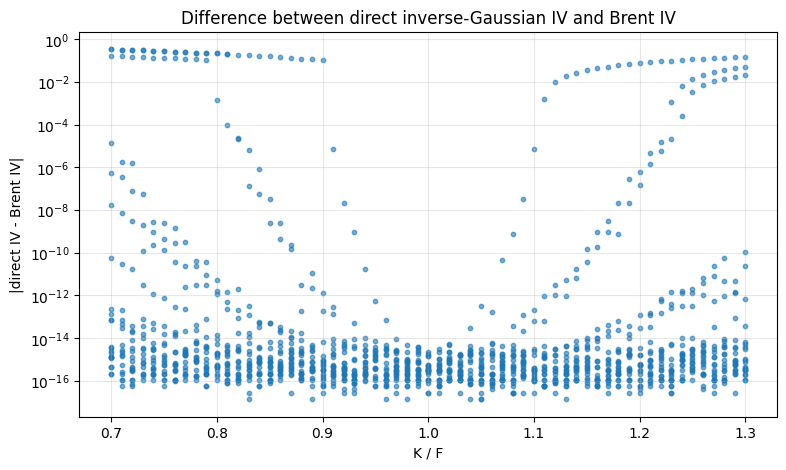

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
plt.scatter(
    df["moneyness_K_over_F"],
    np.abs(df["diff_direct_vs_brent"]),
    s=10,
    alpha=0.6,
)
plt.yscale("log")
plt.xlabel("K / F")
plt.ylabel("|direct IV - Brent IV|")
plt.title("Difference between direct inverse-Gaussian IV and Brent IV")
plt.grid(True, which="both", alpha=0.3)
plt.show()

In [8]:

import warnings
import numpy as np

# 警告が出るケースの特定
F_arr = df["F"].values
K_arr = df["K"].values
T_arr = df["T"].values
C_arr = df["call_price"].values
D_arr = df["D"].values

c = C_arr / (D_arr * F_arr)
k = np.log(K_arr / F_arr)
atm = np.abs(k) < 1e-10
non_atm = ~atm

m = np.where(K_arr[non_atm] > F_arr[non_atm], 1.0, K_arr[non_atm] / F_arr[non_atm])
prob = (1.0 - c[non_atm]) / m
nu = 2.0 / np.abs(k[non_atm])

non_atm_idx = np.where(non_atm)[0]

# 問題あるケースを特定
warn_flags = np.zeros(len(prob), dtype=bool)
for i in range(len(prob)):
    p_c = np.clip(prob[i], np.nextafter(0.0, 1.0), np.nextafter(1.0, 0.0))
    with warnings.catch_warnings(record=True) as w:
        warnings.simplefilter("always")
        from scipy.stats import invgauss
        _ = invgauss.ppf(p_c, mu=nu[i], scale=1.0)
        if w:
            warn_flags[i] = True

# 問題ケースの分析
bad_idx = non_atm_idx[warn_flags]
print(f"問題ケース数: {len(bad_idx)}")
print(f"\n{'row':>5} | {'K/F':>6} | {'T':>7} | {'sigma_true':>10} | {'prob':>12} | {'nu':>8} | {'iv_direct':>10} | {'iv_brent':>10}")
print("-" * 85)
for i in bad_idx:
    print(f"{i:5d} | {K_arr[i]/F_arr[i]:6.3f} | {T_arr[i]:7.4f} | {df['sigma_true'].iloc[i]:10.2f} | "
          f"{prob[warn_flags][list(bad_idx).index(i)]:12.4e} | "
          f"{nu[warn_flags][list(bad_idx).index(i)]:8.2f} | "
          f"{df['iv_direct'].iloc[i]:10.6f} | "
          f"{df['iv_brent'].iloc[i]:10.6f}")


問題ケース数: 18

  row |    K/F |       T | sigma_true |         prob |       nu |  iv_direct |   iv_brent
-------------------------------------------------------------------------------------
   80 |  0.900 |  0.0192 |       0.10 |   1.0000e+00 |    18.98 |   0.102485 |   0.000000
  164 |  1.110 |  0.0192 |       0.10 |   1.0000e+00 |    19.16 |   0.101530 |   0.100000
  387 |  1.050 |  0.0822 |       0.80 |   9.2932e-01 |    40.99 |   0.800000 |   0.800000
  587 |  0.940 |  0.2466 |       0.80 |   8.6751e-01 |    32.32 |   0.800000 |   0.800000
  635 |  1.060 |  0.2466 |       0.80 |   8.6611e-01 |    34.32 |   0.800000 |   0.800000
  827 |  0.930 |  0.5000 |       0.80 |   8.0470e-01 |    27.56 |   0.800000 |   0.800000
  834 |  0.950 |  0.5000 |       0.40 |   9.0901e-01 |    38.99 |   0.400000 |   0.400000
  837 |  0.960 |  0.5000 |       0.20 |   9.6091e-01 |    48.99 |   0.200000 |   0.200000
  864 |  1.030 |  0.5000 |       0.10 |   9.8391e-01 |    67.66 |   0.100000 |   0.100000
  